# Comparaison de strategies multi-agents

Ce notebook permet de lancer plusieurs configurations de l'EDA multi-agent et de comparer :
- la fitness moyenne (`average_test_score`)
- la distance de Hamming moyenne entre agents
- la divergence de KL moyenne entre agents


In [1]:
from pathlib import Path
import sys
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

try:
    import pandas as pd
except ImportError:  # pragma: no cover - depend du setup local
    pd = None
    print("Pandas n'est pas installe : les tableaux seront affiches comme dictionnaires.")

try:
    from IPython.display import display
except ImportError:  # pragma: no cover
    display = print

plt.style.use('seaborn-v0_8')

def find_repo_root(start: Optional[Path] = None) -> Path:
    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path] + list(start_path.parents):
        if (candidate / 'source_code').exists():
            return candidate
    raise RuntimeError('Impossible de localiser la racine du depot.')

REPO_ROOT = find_repo_root()
SOURCE_DIR = REPO_ROOT / 'source_code'
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))
CONFIG_ROOT = REPO_ROOT / 'config'
AGENT_CFG_DIR = CONFIG_ROOT / 'agent'
PROBLEM_CFG_DIR = CONFIG_ROOT / 'problem'
MAIN_CFG_PATH = CONFIG_ROOT / 'config.yaml'

print(f'Repertoire racine: {REPO_ROOT}')
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch utilisera: {DEVICE}')


Repertoire racine: /home/landos/Documents/Supplementary-material
PyTorch utilisera: cuda:0


In [2]:
import os
from typing import Tuple

from eda_strategies.FactoryStrategyEA import FactoryStrategyEA
from environment.qubo import getTensorInstances_QUBO, get_Score_trajectoriesQUBO_cuda

factory = FactoryStrategyEA()

def load_problem_cfg(main_config_path: Path, problem_dir: Path) -> Dict[str, Any]:
    defaults: Dict[str, Any] = dict(
        type_problem='QUBO',
        dim=64,
        type_instance=0,
        nb_instances_test=10,
        nb_restarts=10,
        budget=10000,
        verbose=False,
    )
    cfg = defaults.copy()
    overrides: Dict[str, Any] = {}
    problem_name = None
    if main_config_path.exists():
        with main_config_path.open('r', encoding='utf-8') as fh:
            main_cfg = yaml.safe_load(fh) or {}
        defaults_list = main_cfg.get('defaults', [])
        for entry in defaults_list:
            if isinstance(entry, dict) and 'problem' in entry:
                problem_name = entry['problem']
                break
        overrides = {
            key: main_cfg[key]
            for key in ('nb_instances_test', 'nb_restarts', 'budget', 'verbose')
            if key in main_cfg
        }
    else:
        print(f"Avertissement: {main_config_path} introuvable. Utilisation des valeurs par defaut.")
    problem_key = (problem_name or cfg['type_problem']).lower()
    problem_cfg_path = problem_dir / f'{problem_key}.yaml'
    if problem_cfg_path.exists():
        with problem_cfg_path.open('r', encoding='utf-8') as fh:
            problem_cfg = yaml.safe_load(fh) or {}
        cfg.update(problem_cfg)
    else:
        print(f"Avertissement: {problem_cfg_path} introuvable. Utilisation des valeurs par defaut.")
    cfg.update(overrides)
    cfg['type_problem'] = str(cfg.get('type_problem', 'QUBO'))
    cfg['dim'] = int(cfg.get('dim', 64))
    cfg['type_instance'] = int(cfg.get('type_instance', 0))
    cfg['nb_instances_test'] = int(cfg.get('nb_instances_test', 10))
    cfg['nb_restarts'] = int(cfg.get('nb_restarts', 10))
    cfg['budget'] = int(cfg.get('budget', 10000))
    cfg['verbose'] = bool(cfg.get('verbose', False))
    return cfg

def resolve_agent_cfg_path(main_config_path: Path, agent_dir: Path) -> Path:
    agent_name = None
    if main_config_path.exists():
        with main_config_path.open('r', encoding='utf-8') as fh:
            main_cfg = yaml.safe_load(fh) or {}
        for entry in main_cfg.get('defaults', []):
            if isinstance(entry, dict) and 'agent' in entry:
                agent_name = entry['agent']
                break
    else:
        print(f"Avertissement: {main_config_path} introuvable. Utilisation des valeurs par defaut.")
    agent_key = (agent_name or 'reinforce').lower()
    cfg_path = agent_dir / f'{agent_key}.yaml'
    if not cfg_path.exists():
        print(f"Avertissement: {cfg_path} introuvable. Utilisation de reinforce.yaml.")
        cfg_path = agent_dir / 'reinforce.yaml'
    return cfg_path

def load_base_agent_cfg(config_path: Path) -> Dict[str, Any]:
    defaults: Dict[str, Any] = dict(
        lambda_=20,
        M=4,
        learning_rate=0.0,
        learning_rate_svgd=0.8,
        svgd_alpha=10.0,
        advantage='baseline',
    )
    cfg = defaults.copy()
    if config_path.exists():
        with config_path.open('r', encoding='utf-8') as fh:
            raw_cfg = yaml.safe_load(fh) or {}
        raw_cfg = raw_cfg.copy()
        if 'lambda' in raw_cfg and 'lambda_' not in raw_cfg:
            raw_cfg['lambda_'] = raw_cfg.pop('lambda')
        if 'alpha' in raw_cfg and 'svgd_alpha' not in raw_cfg:
            raw_cfg['svgd_alpha'] = raw_cfg.pop('alpha')
        cfg.update(raw_cfg)
    else:
        print(f"Avertissement: {config_path} introuvable. Utilisation des valeurs par defaut.")
    cfg['lambda_'] = int(cfg['lambda_'])
    cfg['M'] = int(cfg['M'])
    cfg['learning_rate'] = float(cfg.get('learning_rate', 0.0))
    cfg['learning_rate_svgd'] = float(cfg.get('learning_rate_svgd', 0.0))
    cfg['svgd_alpha'] = float(cfg.get('svgd_alpha', 10.0))
    cfg['advantage'] = cfg.get('advantage', 'baseline')
    return cfg

def load_strategy_variants(main_config_path: Path) -> List[Dict[str, Any]]:
    defaults = [
        {'advantage': 'baseline', 'label': 'Baseline'},
        {'advantage': 'globalrankweighted', 'label': 'Global rank weighted'},
        {'advantage': 'peragentrankweighted', 'label': 'Per-agent rank weighted'},
    ]
    if not main_config_path.exists():
        print(f"Avertissement: {main_config_path} introuvable. Utilisation des strategies par defaut.")
        return defaults
    with main_config_path.open('r', encoding='utf-8') as fh:
        main_cfg = yaml.safe_load(fh) or {}
    entries = main_cfg.get('strategy_variants')
    if not isinstance(entries, list):
        return defaults
    variants: List[Dict[str, Any]] = []
    for entry in entries:
        if isinstance(entry, str):
            variants.append({'advantage': entry, 'label': entry})
        elif isinstance(entry, dict):
            adv = entry.get('advantage')
            if not adv:
                continue
            normalized = {'advantage': adv, 'label': entry.get('label', adv)}
            extra = {k: v for k, v in entry.items() if k not in {'advantage', 'label'}}
            normalized.update(extra)
            variants.append(normalized)
    return variants or defaults

DEFAULT_PROBLEM_CFG: Dict[str, Any] = load_problem_cfg(MAIN_CFG_PATH, PROBLEM_CFG_DIR)
AGENT_CFG_PATH = resolve_agent_cfg_path(MAIN_CFG_PATH, AGENT_CFG_DIR)
BASE_AGENT_CFG: Dict[str, Any] = load_base_agent_cfg(AGENT_CFG_PATH)
STRATEGY_VARIANTS: List[Dict[str, Any]] = load_strategy_variants(MAIN_CFG_PATH)


def load_qubo_instances(problem_cfg: Dict[str, Any], *, device: str = DEVICE) -> Tuple[torch.Tensor, int]:
    """Load cached QUBO instances defined by the current problem configuration."""
    type_problem = str(problem_cfg.get('type_problem', 'QUBO')).upper()
    if type_problem != 'QUBO':
        raise ValueError(f"Type de probleme {type_problem} non pris en charge pour le chargement QUBO.")
    dim = int(problem_cfg.get('dim', 64))
    type_instance = int(problem_cfg.get('type_instance', 0))
    nb_instances = int(problem_cfg.get('nb_instances_test', 10))
    nb_restarts = int(problem_cfg.get('nb_restarts', 10))
    instance_path = SOURCE_DIR / 'instances' / 'QUBO'
    path_str = str(instance_path) + os.sep
    try:
        tensor_Q_test = getTensorInstances_QUBO(path_str, nb_instances, nb_restarts, dim, type_instance, device, 'test')
        return tensor_Q_test, dim
    except FileNotFoundError as exc:
        fallback_dim = 64
        if dim == fallback_dim:
            raise
        print(f"Instances QUBO dim={dim} introuvables ({exc}). Repli vers dim={fallback_dim}.")
        tensor_Q_test = getTensorInstances_QUBO(path_str, nb_instances, nb_restarts, fallback_dim, type_instance, device, 'test')
        return tensor_Q_test, fallback_dim


In [3]:
def _prepare_strategy_cfg(custom_cfg: Dict[str, Any]) -> Dict[str, Any]:
    cfg = BASE_AGENT_CFG.copy()
    cfg.update(custom_cfg)
    if 'lambda' in cfg and 'lambda_' not in cfg:
        cfg['lambda_'] = cfg.pop('lambda')
    cfg.setdefault('label', f"M={cfg['M']} / lambda={cfg['lambda_']}")
    return cfg


def run_strategy(strategy_cfg: Dict[str, Any], problem_cfg: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    problem_cfg = (problem_cfg or DEFAULT_PROBLEM_CFG).copy()
    cfg = _prepare_strategy_cfg(strategy_cfg)
    label = cfg.pop('label')
    lambda_ = int(cfg['lambda_'])
    M = int(cfg['M'])
    advantage_cfg = cfg.get('advantage', 'baseline')

    nb_instances = int(problem_cfg['nb_instances_test'])
    nb_restarts = int(problem_cfg['nb_restarts'])
    budget = int(problem_cfg['budget'])
    verbose = bool(problem_cfg.get('verbose', False))

    tensor_Q_test, dim = load_qubo_instances(problem_cfg)
    strategy = factory.createStrategyEA(
        'PPO-EDA',
        dim,
        lambda_,
        DEVICE,
        None,
        M,
        learning_rate=float(cfg.get('learning_rate', 0.0)),
        learning_rate_svgd=float(cfg.get('learning_rate_svgd', 0.0)),
        enable_visualization=False,
        svgd_alpha=float(cfg.get('svgd_alpha', 10.0)),
        advantage_cfg=advantage_cfg,
    ).to(DEVICE)

    scores, history = get_Score_trajectoriesQUBO_cuda(
        strategy,
        dim,
        nb_instances,
        nb_restarts,
        budget,
        lambda_,
        tensor_Q_test,
        DEVICE,
        verbose,
        name_file=None,
        enable_visualization=False,
        return_history=True,
    )

    history = history or {}
    hamming_history = history.get('avg_hamming', [])
    kl_history = history.get('avg_kl', [])
    best_fitness_history = history.get('best_fitness', [])
    # passer les - en +
    best_fitness_history = [-x for x in best_fitness_history]

    summary = {
        'label': label,
        'config': cfg,
        'average_test_score': float(np.mean(scores)),
        'best_average_fitness': float(best_fitness_history[-1]) if best_fitness_history else float('nan'),
        'final_hamming': float(hamming_history[-1]) if hamming_history else float('nan'),
        'mean_hamming': float(np.mean(hamming_history)) if hamming_history else float('nan'),
        'final_kl': float(kl_history[-1]) if kl_history else float('nan'),
        'mean_kl': float(np.mean(kl_history)) if kl_history else float('nan'),
        'runtime': history.get('runtime', []),
        'hamming_history': hamming_history,
        'kl_history': kl_history,
        'best_fitness_history': best_fitness_history,
    }
    return summary



In [4]:
strategy_variants = STRATEGY_VARIANTS

strategies: List[Dict[str, Any]] = []
for variant in strategy_variants:
    if not isinstance(variant, dict):
        continue
    variant = variant.copy()
    advantage_name = variant.pop('advantage', None)
    if advantage_name is None:
        continue
    label_prefix = variant.pop('label', advantage_name)
    append_params = bool(variant.pop('append_params', True))
    overrides = {k: v for k, v in variant.items()}
    norm_overrides = overrides.copy()
    if 'lambda' in norm_overrides and 'lambda_' not in norm_overrides:
        norm_overrides['lambda_'] = norm_overrides.pop('lambda')
    if 'alpha' in norm_overrides and 'svgd_alpha' not in norm_overrides:
        norm_overrides['svgd_alpha'] = norm_overrides.pop('alpha')
    preview_cfg = BASE_AGENT_CFG.copy()
    preview_cfg.update(norm_overrides)
    if append_params:
        label = f"{label_prefix} (M={preview_cfg['M']}, lambda={preview_cfg['lambda_']}, lr_svgd={preview_cfg['learning_rate_svgd']}, alpha={preview_cfg['svgd_alpha']})"
    else:
        label = label_prefix
    strategy_entry = {'label': label, 'advantage': advantage_name}
    strategy_entry.update(norm_overrides)
    strategies.append(strategy_entry)

strategies


[{'label': 'Baseline (M=3, lambda=30, lr_svgd=1.0, alpha=15.0)',
  'advantage': 'baseline'},
 {'label': 'Global rank weighted (M=3, lambda=30, lr_svgd=1.0, alpha=15.0)',
  'advantage': 'globalrankweighted'},
 {'label': 'Per-agent rank weighted (M=3, lambda=30, lr_svgd=1.0, alpha=15.0)',
  'advantage': 'peragentrankweighted'}]

In [5]:
results: List[Dict[str, Any]] = []
for strat in strategies:
    print(f"[RUN] {strat.get('label', strat)}")
    summary = run_strategy(strat)
    results.append(summary)
print('Comparaison terminee.')

rows = [
    {
        'label': r['label'],
        'advantage': r['config'].get('advantage'),
        'best_avg_fitness': r['best_average_fitness'],
        'avg_test_score': r['average_test_score'],
        'final_hamming': r['final_hamming'],
        'final_kl': r['final_kl'],
        'mean_hamming': r['mean_hamming'],
        'mean_kl': r['mean_kl'],
    }
    for r in results
]

if pd is not None and rows:
    display(pd.DataFrame(rows))

[RUN] Baseline (M=3, lambda=30, lr_svgd=1.0, alpha=15.0)


100%|██████████| 333/333 [00:02<00:00, 135.40it/s, avg_hamming=65.7, avg_kl=1.04, bestScore=-1.54e+3, current_score=-1.53e+3, leader=2] 


Per-agent summary:
Agent 0: avg_best_score=-1502.3199, theta_mean=-0.019117
Agent 1: avg_best_score=-1503.7600, theta_mean=-0.016707
Agent 2: avg_best_score=-1506.6200, theta_mean=-0.002456
[RUN] Global rank weighted (M=3, lambda=30, lr_svgd=1.0, alpha=15.0)


100%|██████████| 333/333 [00:02<00:00, 166.30it/s, avg_hamming=60.9, avg_kl=0.814, bestScore=-1.55e+3, current_score=-1.53e+3, leader=2]


Per-agent summary:
Agent 0: avg_best_score=-1494.0800, theta_mean=-0.009436
Agent 1: avg_best_score=-1475.1200, theta_mean=-0.027311
Agent 2: avg_best_score=-1499.6200, theta_mean=0.012599
[RUN] Per-agent rank weighted (M=3, lambda=30, lr_svgd=1.0, alpha=15.0)


100%|██████████| 333/333 [00:01<00:00, 167.82it/s, avg_hamming=57.4, avg_kl=0.917, bestScore=-1.58e+3, current_score=-1.57e+3, leader=0]


Per-agent summary:
Agent 0: avg_best_score=-1546.9399, theta_mean=-0.050785
Agent 1: avg_best_score=-1537.4600, theta_mean=-0.039107
Agent 2: avg_best_score=-1544.0599, theta_mean=-0.051209
Comparaison terminee.


,label,advantage,best_avg_fitness,avg_test_score,final_hamming,final_kl,mean_hamming,mean_kl
0,"Baseline (M=3, lambda=30, lr_svgd=1.0, alpha=1...",baseline,1541.260010,-1541.260010,65.727999,1.038234,74.951421,0.784945
1,"Global rank weighted (M=3, lambda=30, lr_svgd=...",globalrankweighted,1549.319946,-1549.319946,60.918667,0.814437,77.219075,0.515223
2,"Per-agent rank weighted (M=3, lambda=30, lr_sv...",peragentrankweighted,1581.099976,-1581.099976,57.352666,0.917441,74.244462,0.567335


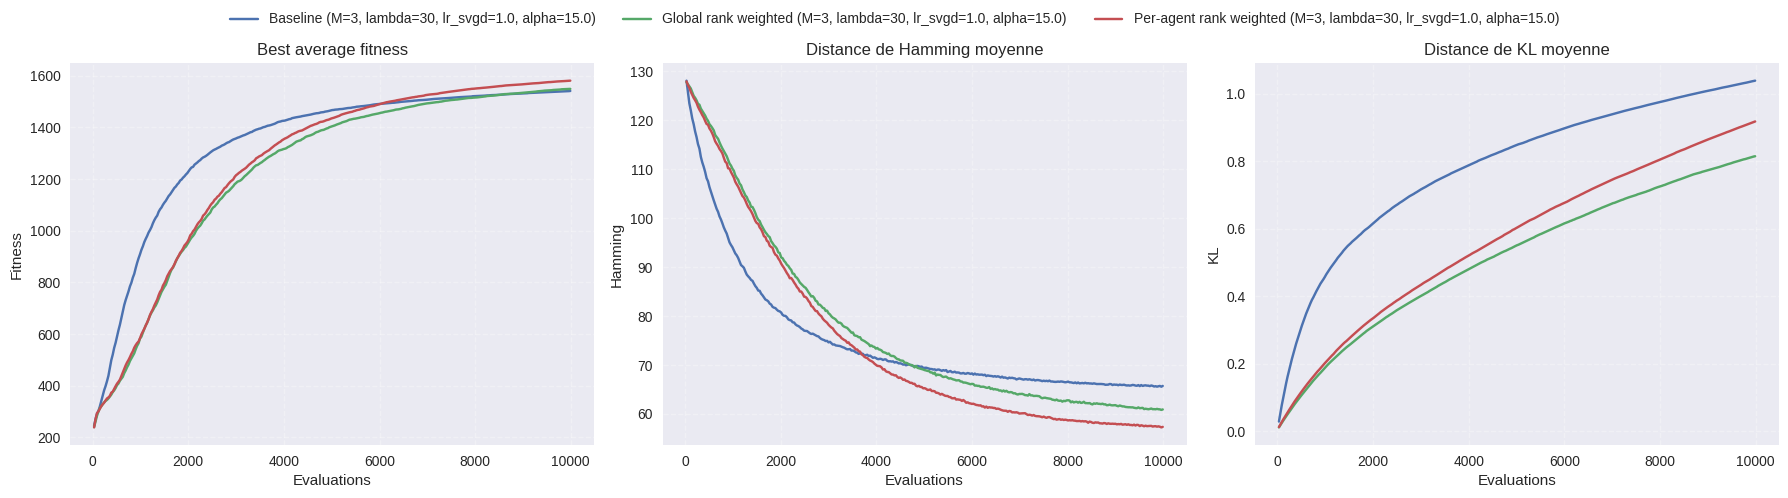

In [6]:
if results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for result in results:
        label = result['label']
        runtime = result['runtime']
        best_history = result['best_fitness_history']
        if best_history:
            steps = runtime[:len(best_history)] if runtime else list(range(1, len(best_history) + 1))
            axes[0].plot(steps, best_history, label=label)

    axes[0].set_title('Best average fitness')
    axes[0].set_xlabel('Evaluations')
    axes[0].set_ylabel('Fitness')
    axes[0].grid(True, linestyle='--', alpha=0.3)

    for result in results:
        if result['hamming_history']:
            steps = result['runtime'][:len(result['hamming_history'])] if result['runtime'] else list(range(1, len(result['hamming_history']) + 1))
            axes[1].plot(steps, result['hamming_history'], label=result['label'])
    axes[1].set_title('Distance de Hamming moyenne')
    axes[1].set_xlabel('Evaluations')
    axes[1].set_ylabel('Hamming')
    axes[1].grid(True, linestyle='--', alpha=0.3)

    for result in results:
        if result['kl_history']:
            steps = result['runtime'][:len(result['kl_history'])] if result['runtime'] else list(range(1, len(result['kl_history']) + 1))
            axes[2].plot(steps, result['kl_history'], label=result['label'])
    axes[2].set_title('Distance de KL moyenne')
    axes[2].set_xlabel('Evaluations')
    axes[2].set_ylabel('KL')
    axes[2].grid(True, linestyle='--', alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=min(len(handles), 3))

    fig.tight_layout(rect=(0, 0, 1, 0.95))
else:
    print('Aucun resultat a tracer pour le moment.')
